# Principal Component Analysis (PCA)

## What is PCA?

**Principal Component Analysis (PCA)** is an **unsupervised dimensionality reduction** preprocessing technique that transforms high-dimensional data into a smaller set of **Principal Components (PCs)** while preserving the **maximum variance (information)**.

> PCA creates **new features**; it does **not** simply remove existing features.

---

# Why do we need PCA?

- Reduce high-dimensional data.
- Remove multicollinearity (highly correlated features).
- Reduce model complexity and overfitting.
- Speed up model training.
- Visualize high-dimensional data in **2D** or **3D**.

---

# Workflow

```text
Dataset
    │
    ▼
Scaling (Recommended)
    │
    ▼
PCA
    │
    ▼
Principal Components
    │
    ▼
Reduced Dataset
    │
    ▼
Machine Learning Model
```

---

# How PCA Works

1. Scale the numerical features.
2. Calculate the variance of the data.
3. Create Principal Components.
4. Keep the components with the highest variance.
5. Discard less informative components.

---

# Variance

Variance measures the spread of data.

- Higher Variance → More Information ✅
- Lower Variance → Less Information ❌

PCA preserves components with the **highest variance**.

---

# Principal Components

Principal Components are **new features** created by combining the original features.

```text
Original Features
X1  X2  X3  X4

        │
        ▼

PC1 → Highest Variance
PC2 → Second Highest Variance
PC3 → Third Highest Variance
```

---

# n_components

Controls the number of Principal Components.

```python
PCA(n_components=2)
```

Creates exactly **2 components**.

```python
PCA(n_components=0.95)
```

Automatically keeps enough components to preserve **95% variance**.

---

# Explained Variance Ratio

`explained_variance_ratio_` shows how much information each Principal Component retains.

Example

```text
PC1 → 60%

PC2 → 25%

PC3 → 10%

PC4 → 5%
```

PC1 + PC2 retain **85%** of the total information.

---

# Why Scaling Before PCA?

PCA is **variance-based**.

Features with larger values dominate the variance.

Therefore, always use:

- StandardScaler ✅
- MinMaxScaler

before applying PCA.

---

# When to Use PCA?

- High-dimensional datasets.
- Multicollinearity exists.
- Model is overfitting.
- Faster training is required.
- Data visualization (2D/3D).
- Before distance-based algorithms (KNN, KMeans, SVM).

---

# When NOT to Use PCA?

- Dataset has very few features.
- Model already performs well.
- Feature interpretability is important.
- Dataset contains only categorical features.

---

# PCA + KMeans Workflow

```text
Dataset
    │
    ▼
Missing Value Handling
    │
    ▼
Encoding
    │
    ▼
Scaling
    │
    ▼
PCA
    │
    ▼
KMeans
    │
    ▼
Clusters
```

---

# Advantages

- Reduces dimensionality.
- Reduces multicollinearity.
- Prevents overfitting.
- Faster model training.
- Better visualization.
- Preserves maximum information.

---

# Disadvantages

- Creates new features (less interpretable).
- Some information is lost.
- Sensitive to scaling.
- Not suitable for only categorical data.

---

# Syntax

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)
```

---

# Important Points

- PCA is an **unsupervised preprocessing technique**.
- Works only on **numerical data**.
- Creates **new features (Principal Components)**.
- Preserves **maximum variance**.
- Scaling is highly recommended before PCA.
- Commonly used before **KMeans, KNN, and SVM**.

---

# Interview Questions

**Q. What is PCA?**

Dimensionality reduction technique that creates Principal Components while preserving maximum variance.

**Q. Why use PCA?**

To reduce dimensions, remove multicollinearity, improve visualization, and reduce overfitting.

**Q. Does PCA remove features?**

No. It creates new features by combining the original features.

**Q. What is `explained_variance_ratio_`?**

It shows the percentage of variance explained by each Principal Component.

**Q. Why use StandardScaler before PCA?**

Because PCA is variance-based, and scaling prevents features with larger values from dominating.

# Elbow Method

## What is the Elbow Method?

The **Elbow Method** is a technique used to determine the **optimal number of clusters (K)** in the **K-Means Clustering** algorithm.

It works by calculating the **Within-Cluster Sum of Squares (WCSS)** (also called **Inertia**) for different values of **K**.

---

# Workflow

```text
Dataset
    │
    ▼
Choose Different K Values
(K = 1, 2, 3, ...)
    │
    ▼
Train KMeans Model
    │
    ▼
Calculate WCSS (Inertia)
    │
    ▼
Plot K vs WCSS
    │
    ▼
Choose the "Elbow Point"
```

---

# What is WCSS (Inertia)?

**WCSS (Within-Cluster Sum of Squares)** measures the total distance between data points and their respective cluster centroids.

- Lower WCSS → Better clustering.
- Increasing K decreases WCSS, but after a certain point the improvement becomes very small.

---

# Elbow Graph

```text
WCSS
 ^
 |
 |\
 | \
 |  \
 |   \
 |    \__
 |       \____
 +------------------------>
   1  2  3  4  5  6  7
          ↑
      Elbow Point
   (Best K Value)
```

The point where the graph bends like an **elbow** is considered the **optimal number of clusters**.

---

# Why Use the Elbow Method?

- Select the best value of **K**.
- Avoid too many or too few clusters.
- Improve clustering performance.

---

# Syntax

```python
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
```

---

# Important Points

- Used only with **K-Means Clustering**.
- Uses **WCSS (Inertia)** to evaluate clusters.
- Best K is chosen at the **Elbow Point**.
- Lower WCSS indicates better clustering, but very large K may lead to overfitting.

---

# Interview Questions

**Q. What is the Elbow Method?**

A technique used to find the optimal number of clusters (K) by plotting **WCSS (Inertia)** against different K values.

**Q. What is WCSS (Inertia)?**

The sum of squared distances between data points and their assigned cluster centroids.

**Q. Why is it called the Elbow Method?**

Because the graph forms an **elbow-like bend**, and that bend indicates the optimal value of **K**.

In [21]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(
    "../datasets/Mall_Customers.csv",
    na_values=["None"]
)

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [22]:

# Remove CustomerID
# (It is only an identifier and not useful for PCA)


X = df.drop(columns="CustomerID")


# Separate Numerical and Categorical Columns

num_cols = X.select_dtypes(include="number").columns

cat_cols = X.select_dtypes(include="object").columns

print(num_cols)
print(cat_cols)


Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')
Index(['Gender'], dtype='str')


/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_45216/3113654010.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [23]:


# Numerical Pipeline

num_pipeline = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="mean")),

        ("scaler", StandardScaler())

    ]

)

# Categorical Pipeline

cat_pipeline = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)


In [24]:

# Column Transformer

preprocessing = ColumnTransformer(

    transformers=[

        ("num", num_pipeline, num_cols),

        ("cat", cat_pipeline, cat_cols)

    ]

)

# Preprocess Dataset

updated_df = preprocessing.fit_transform(X)

print(updated_df.shape)


(200, 5)


In [25]:

# PCA with 2 Components

pca = PCA(n_components=2)

pca_values = pca.fit_transform(updated_df)

print(pca_values)


[[-0.57572361 -1.68487363]
 [-1.62359494 -1.72648138]
 [ 0.27961435 -1.72531425]
 [-1.51106396 -1.79620462]
 [-0.09546842 -1.7073466 ]
 [-1.53580344 -1.75857647]
 [ 1.03564413 -1.62747944]
 [-1.97915918 -1.73817968]
 [ 2.68028034 -1.42925712]
 [-1.02454893 -1.66667214]
 [ 2.53113695 -1.43655689]
 [-1.51023184 -1.68802373]
 [ 1.95025617 -1.52756054]
 [-1.46644971 -1.64266722]
 [ 1.03895218 -1.44106096]
 [-1.52575968 -1.53280315]
 [ 0.2377451  -1.54415148]
 [-1.27279373 -1.48390972]
 [ 1.35574248 -1.3221625 ]
 [-1.48886023 -1.53487932]
 [ 0.32986561 -1.31519863]
 [-1.2157888  -1.37000103]
 [ 1.60914245 -1.34429042]
 [-0.91367626 -1.32326287]
 [ 1.76323423 -1.22814291]
 [-1.2656001  -1.22164371]
 [ 0.81535969 -1.26029561]
 [-0.3874535  -1.19066999]
 [ 0.58821397 -1.2284788 ]
 [-1.80411186 -1.31252823]
 [ 2.43405009 -1.01789575]
 [-1.52378699 -1.26257495]
 [ 2.07534868 -0.91400218]
 [-2.10329057 -1.05811763]
 [ 1.50274229 -1.04530138]
 [-1.74714879 -1.15699027]
 [ 1.06495778 -1.02062962]
 

In [26]:

# Shape after PCA

print("Shape after PCA :", pca_values.shape)


Shape after PCA : (200, 2)


In [27]:

# Explained Variance Ratio

print("Explained Variance Ratio")

print(pca.explained_variance_ratio_)


Explained Variance Ratio
[0.38132566 0.28707805]


In [28]:


# Total Variance Captured

print("Total Variance")

print(sum(pca.explained_variance_ratio_))


Total Variance
0.6684037061176664


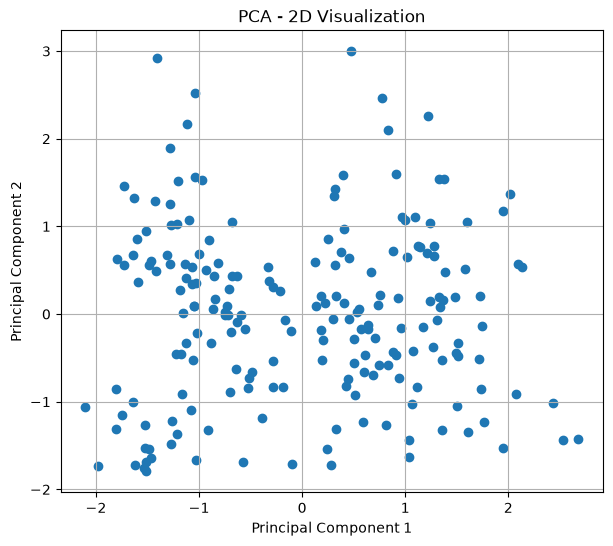

In [30]:

# 2D Visualization

plt.figure(figsize=(7,6))

plt.scatter(

    pca_values[:,0],

    pca_values[:,1]
   

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization")

plt.grid(True)

plt.show()

# PCA + KMeans

In [ ]:


from sklearn.cluster import KMeans

kmeans = KMeans(

    n_clusters=3,

    random_state=42

)

clusters = kmeans.fit_predict(pca_values)

print(clusters)

[2 2 2 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 0 0 0 2 0 0 2 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0
 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 1
 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1]


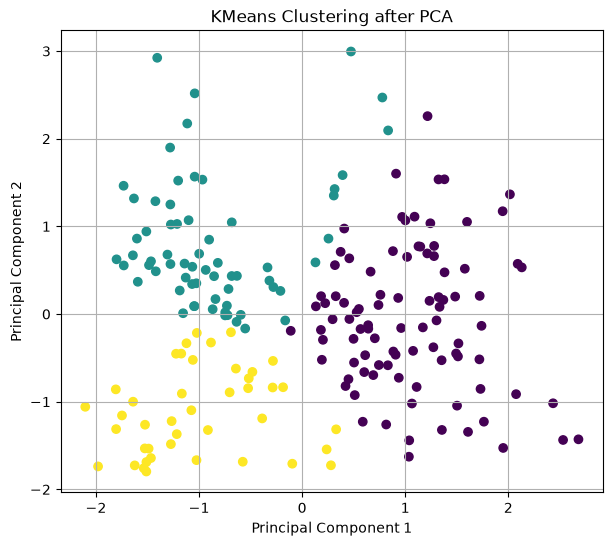

In [ ]:
# PCA + KMeans Visualization
plt.figure(figsize=(7,6))

plt.scatter(

    pca_values[:,0],

    pca_values[:,1],

    c=clusters

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("KMeans Clustering after PCA")

plt.grid(True)

plt.show()